# Verify variants — filtered (`hvg5000`) vs non-filtered (`all_genes`)

A re-runnable audit of the preprocessing outputs and the PCA-vs-scGPT comparison inputs:

1. Gene-count flow (`convert` HVG → `scgpt` OOV-drop)
2. Why scGPT drops genes (`id_in_vocab`)
3. Cell alignment across files
4. What `.X` holds, and where `X_pca` / `X_scGPT` come from
5. `hvg5000` vs `all_genes` gene sets
6. Cross-variant embedding similarity (filtered vs non-filtered `X_scGPT`)
7. **UMAP — PCA vs scGPT, filtered vs non-filtered** (colored by cancer type + paclitaxel viability)

See `docs/steps/02-preprocessing-and-embeddings.md` for the narrative.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

import sys

ROOT = next(q for q in [Path.cwd(), *Path.cwd().parents] if (q / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths, targets_filename

# Derived, not hardcoded (12.08.2026). This was an absolute /Users/... path, so the notebook ran
# on exactly one machine; layout.py is the path contract every other stage already uses.
SCORE = DEFAULT_CTRP_SCORE
DATA_ROOT = PipelinePaths.build(None, 'hvg5000', SCORE).processed_dir.parent
VARIANTS = ['hvg5000', 'all_genes']
FILES = {
    'convert':    'SCP542_CCLE.h5ad',
    'embeddings': 'SCP542_CCLE_scGPT_human_embeddings.h5ad',
    # targets_filename() appends the score -- the bare '..._with_targets.h5ad' literal that
    # was here has not been written by the pipeline since 11.08.2026.
    'targets':    targets_filename(SCORE),
}
TARGETS = FILES['targets']
SEED = 42

def load(variant, stage, backed='r'):
    return sc.read_h5ad(DATA_ROOT / variant / FILES[stage], backed=backed)

## 1. Gene-count flow per variant

`convert` applies the HVG filter; `scgpt` then drops out-of-vocabulary (OOV) genes.

In [2]:
rows = []
for v in VARIANTS:
    g = {s: load(v, s).n_vars for s in FILES}
    rows.append({'variant': v, 'convert (HVG)': g['convert'],
                 'embeddings (post-OOV)': g['embeddings'], 'targets': g['targets'],
                 'OOV dropped': g['convert'] - g['embeddings']})
pd.DataFrame(rows).set_index('variant')

,convert (HVG),embeddings (post-OOV),targets,OOV dropped
variant,,,,
hvg5000,5000,4765,4765,235
all_genes,22722,21332,21332,1390


## 2. Why does scGPT drop genes?

scGPT has a fixed gene vocabulary; genes not in it (`id_in_vocab == -1`) cannot be tokenized, so `gen_embeds.py` removes them before embedding.

In [3]:
for v in VARIANTS:
    emb = load(v, 'embeddings')
    if 'id_in_vocab' in emb.var.columns:
        iv = emb.var['id_in_vocab'].astype(int)
        print(f'{v}: in-vocab (id>=0) = {(iv >= 0).sum()},  OOV (== -1) = {(iv < 0).sum()}')
    else:
        print(f'{v}: embeddings already subset to in-vocab genes -> n_vars = {emb.n_vars}')

hvg5000: in-vocab (id>=0) = 4765,  OOV (== -1) = 0


all_genes: in-vocab (id>=0) = 21332,  OOV (== -1) = 0


## 3. Cell alignment across files

The PCA baseline is computed from the `convert` counts and stored in the `targets` file, so cells must share the same order. Must be `True` for every variant.

In [4]:
for v in VARIANTS:
    a, b, c = load(v, 'convert'), load(v, 'embeddings'), load(v, 'targets')
    ok = np.array_equal(a.obs_names, b.obs_names) and np.array_equal(b.obs_names, c.obs_names)
    print(f'{v}: convert == embeddings == targets cell order -> {ok}  (n_cells = {c.n_obs})')

hvg5000: convert == embeddings == targets cell order -> True  (n_cells = 53513)


all_genes: convert == embeddings == targets cell order -> True  (n_cells = 53513)


## 4. What `.X` holds, and where `X_pca` / `X_scGPT` come from

The `targets` `.X` stays **CPM**; `X_scGPT` is 512-d (from the in-vocab genes); `X_pca` is 50-d, computed on the **full convert gene set** (HVG-5000 or all).

In [5]:
for v in VARIANTS:
    t = load(v, 'targets', backed=None)
    X = t.X
    Xd = X[:200].toarray() if sp.issparse(X) else np.asarray(X[:200])
    kind = 'CPM (raw-ish)' if Xd.max() > 100 else 'log-normalized'
    print(f'{v}:')
    print(f'  .X genes={t.n_vars}  max={Xd.max():.1f}  mean row-sum={Xd.sum(1).mean():,.0f}  -> {kind}')
    print(f'  X_scGPT={t.obsm["X_scGPT"].shape}  X_pca={t.obsm["X_pca"].shape}'
          f'  (X_pca built from {load(v, "convert").n_vars} convert genes)')

hvg5000:
  .X genes=4765  max=90079.0  mean row-sum=320,777  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 512)  (X_pca built from 5000 convert genes)


all_genes:
  .X genes=21332  max=90079.0  mean row-sum=988,895  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 512)  (X_pca built from 22722 convert genes)


## 5. `hvg5000` vs `all_genes` gene sets

In [6]:
hvg_conv = set(load('hvg5000', 'convert').var_names)
hvg_emb  = set(load('hvg5000', 'embeddings').var_names)
all_conv = set(load('all_genes', 'convert').var_names)
all_emb  = set(load('all_genes', 'embeddings').var_names)
print(f'HVG-5000 selected:                  {len(hvg_conv)}')
print(f'  in scGPT vocab (embedded):        {len(hvg_emb)}  ({len(hvg_conv - hvg_emb)} OOV)')
print(f'Full transcriptome:                 {len(all_conv)}')
print(f'  in scGPT vocab (embedded):        {len(all_emb)}  ({len(all_conv - all_emb)} OOV)')

HVG-5000 selected:                  5000
  in scGPT vocab (embedded):        4765  (235 OOV)
Full transcriptome:                 22722
  in scGPT vocab (embedded):        21332  (1390 OOV)


## 6. Cross-variant embedding similarity

The filtered and non-filtered `X_scGPT` are computed from different gene inputs, so they should
differ — but how much? (High similarity = scGPT is robust to the gene set.)

In [7]:
h = load('hvg5000', 'targets', backed=None)
a = load('all_genes', 'targets', backed=None)
Xh, Xa = np.asarray(h.obsm['X_scGPT']), np.asarray(a.obsm['X_scGPT'])
assert np.array_equal(h.obs_names, a.obs_names)
cos = (Xh * Xa).sum(1) / (np.linalg.norm(Xh, axis=1) * np.linalg.norm(Xa, axis=1) + 1e-9)
print(f'identical? {np.array_equal(Xh, Xa)} | max|diff|={np.abs(Xh-Xa).max():.3f} '
      f'| mean|diff|={np.abs(Xh-Xa).mean():.3f}')
print(f'per-cell cosine sim (filtered vs non-filtered X_scGPT): '
      f'mean={cos.mean():.3f}  min={cos.min():.3f}  max={cos.max():.3f}')

identical? False | max|diff|=0.204 | mean|diff|=0.014
per-cell cosine sim (filtered vs non-filtered X_scGPT): mean=0.918  min=0.697  max=0.975


## 7. UMAP — PCA vs scGPT, filtered vs non-filtered

PCA (left of each pair) forms discrete tissue **islands**; scGPT a continuous shared **manifold**.
Top row colored by cancer type, bottom by paclitaxel viability. **Compute-heavy** (4 UMAPs on ~53k cells).

In [8]:
PANELS = [
    ('hvg5000', 'X_pca',   'hvg5000 (filtered)\nPCA'),
    ('hvg5000', 'X_scGPT', 'hvg5000 (filtered)\nscGPT'),
    ('all_genes', 'X_pca',   'all_genes (non-filtered)\nPCA'),
    ('all_genes', 'X_scGPT', 'all_genes (non-filtered)\nscGPT'),
]
adatas = {v: load(v, 'targets', backed=None) for v in VARIANTS}
umaps = {}
for variant, rep, _ in PANELS:
    print('UMAP', variant, rep, '...')
    ad = adatas[variant]
    nk = f'nn_{rep}'
    sc.pp.neighbors(ad, use_rep=rep, random_state=SEED, key_added=nk)
    sc.tl.umap(ad, random_state=SEED, neighbors_key=nk)
    umaps[(variant, rep)] = ad.obsm['X_umap'].copy()

UMAP hvg5000 X_pca ...


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP hvg5000 X_scGPT ...


UMAP all_genes X_pca ...


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP all_genes X_scGPT ...


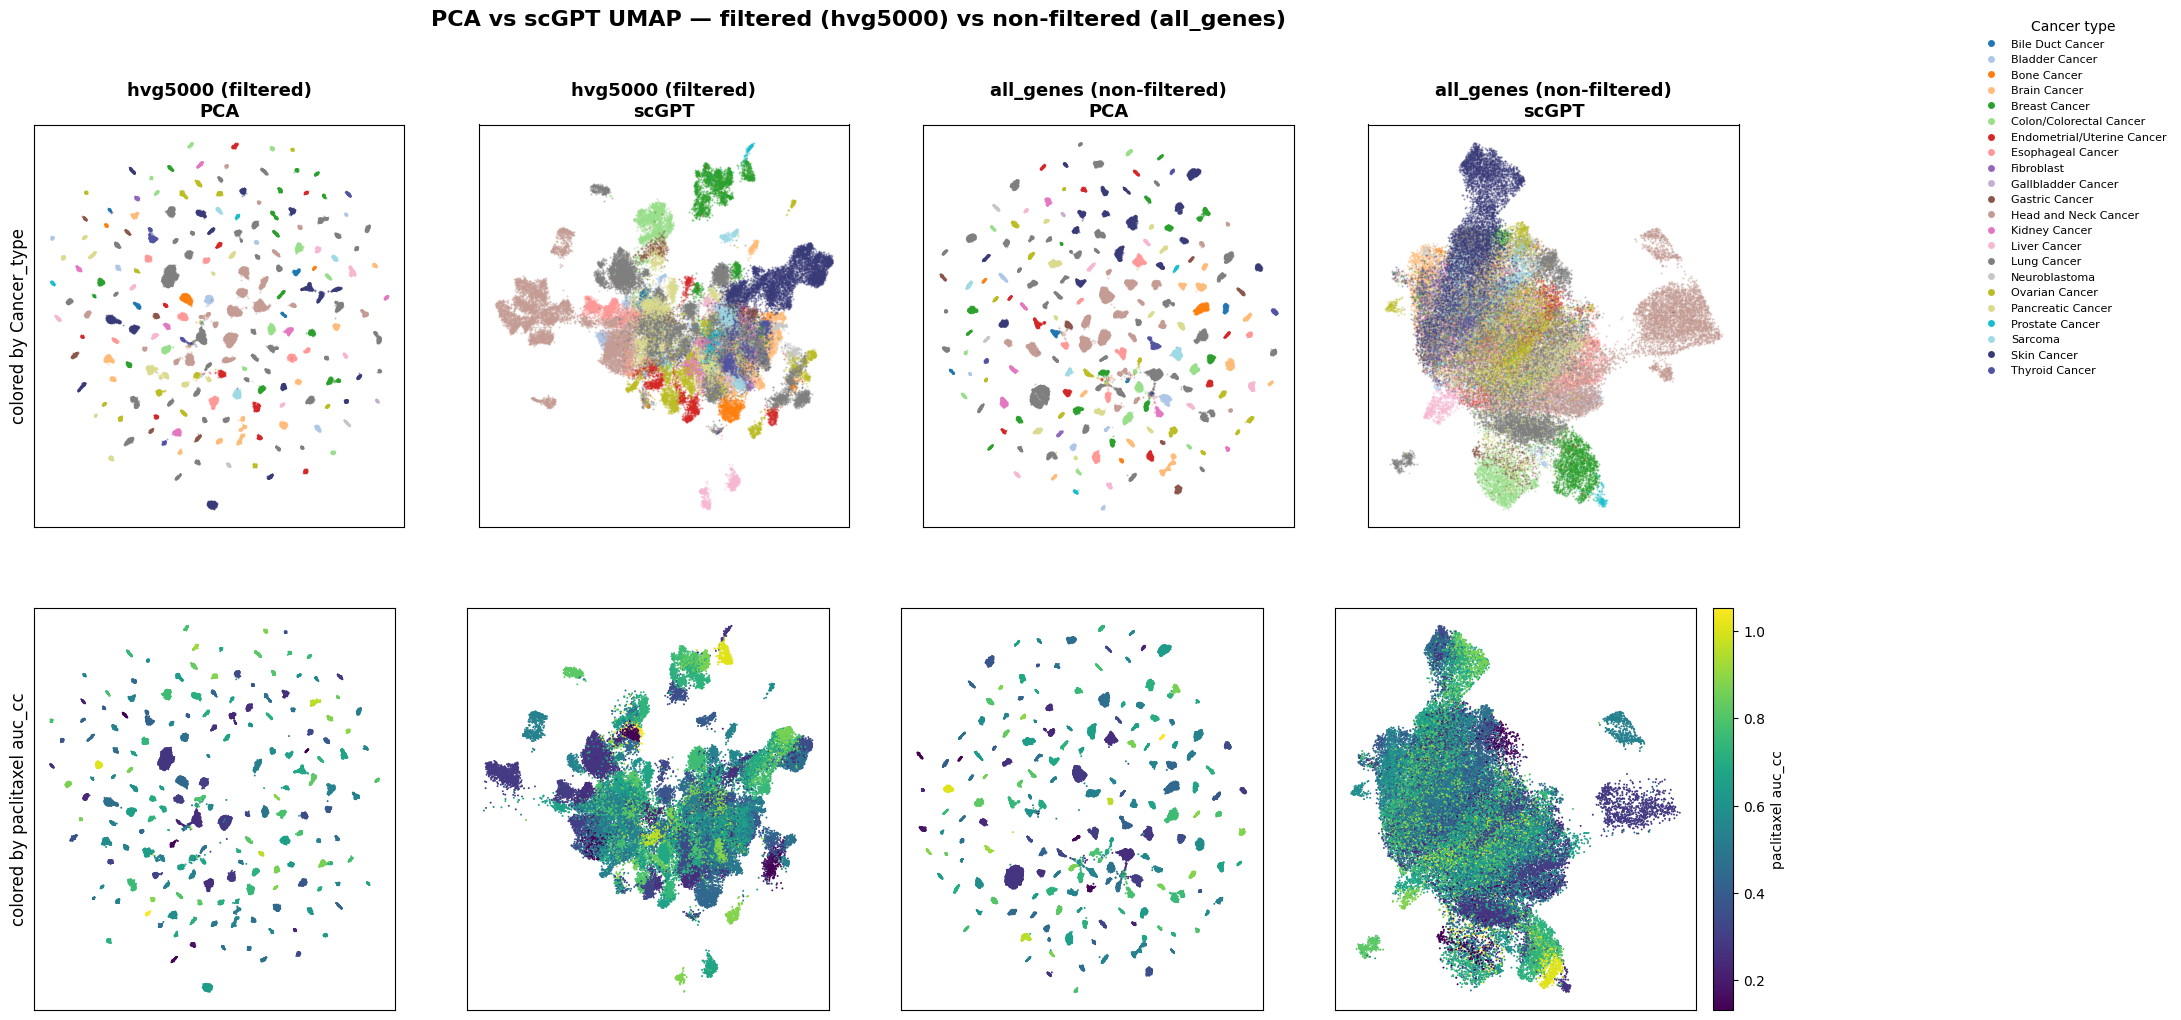

In [9]:
ref = adatas['hvg5000']
cancer = ref.obs['Cancer_type'].astype('category')
cats = list(cancer.cat.categories)
# Was obs['viability_paclitaxel'] until 13.08.2026 (Gate 5). That column is a leftover of the
# retired single-task paclitaxel progression and NOTHING IN scripts/ WRITES IT ANY MORE, so the
# rebuilt h5ads do not carry it and this cell raised KeyError. Paclitaxel is one of the eleven panel
# drugs, so the same quantity is available on the CURRENT target: its column of Y_ctrp, which is the
# line's auc_cc broadcast to that line's cells. The figure keeps its meaning and gains the target the
# project actually trains on -- but it is a DIFFERENT MEASURE from the old viability, so the panel is
# relabelled rather than silently reinterpreted.
_drugs = list(ref.uns['ctrp_drugs'])
_j = _drugs.index('paclitaxel')
_obs_mask = np.asarray(ref.obsm['M_ctrp'], dtype=bool)[:, _j]
via = np.where(_obs_mask, np.asarray(ref.obsm['Y_ctrp'], dtype=float)[:, _j], np.nan)
palette = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)
colors = {c: palette[i % len(palette)] for i, c in enumerate(cats)}

fig, axes = plt.subplots(2, 4, figsize=(22, 11.5))
sca = None
for j, (variant, rep, label) in enumerate(PANELS):
    U = umaps[(variant, rep)]
    ax = axes[0, j]
    for c in cats:
        m = cancer.values == c
        ax.scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=colors[c], linewidths=0)
    ax.set_title(label, fontsize=13, fontweight='bold'); ax.set_xticks([]); ax.set_yticks([])
    ax = axes[1, j]
    sca = ax.scatter(U[:, 0], U[:, 1], s=2, c=via, cmap='viridis', linewidths=0)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('colored by Cancer_type', fontsize=12)
axes[1, 0].set_ylabel('colored by paclitaxel auc_cc', fontsize=12)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[c], markersize=6, label=c) for c in cats]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.005, 0.98), fontsize=8, title='Cancer type', frameon=False)
fig.colorbar(sca, ax=list(axes[1, :]), fraction=0.015, pad=0.01, label='paclitaxel auc_cc')
fig.suptitle('PCA vs scGPT UMAP — filtered (hvg5000) vs non-filtered (all_genes)', fontsize=16, fontweight='bold')
OUT_EMB = ROOT / 'notebooks' / 'outputs' / 'embeddings'   # resolved, not cwd-relative (13.08.2026)
OUT_EMB.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_EMB / "variants.png")
plt.show()

## 8. Cancer-type UMAPs — tissue bias, PCA vs scGPT (slide figures)

Headline latent-space validation of the core hypothesis: **standard PCA clusters cells into discrete
tissue-of-origin islands (memorizing the cell line); scGPT projects them onto a continuous shared
pan-cancer manifold.** Two figures, both colored by `Cancer_type`, computed from the stored embeddings
(`obsm["X_pca"]` / `obsm["X_scGPT"]`; backed read so the big `.X` stays on disk):

1. **2-panel** (`all_genes`) — the clean headline figure → `outputs/embeddings/umap_cancertype_pca_vs_scgpt.png` (dpi 300).
2. **Full sweep grid** — PCA vs scGPT across **every gene-set variant** (1k/2k/3k/5k/all_genes), showing
   the split holds at all gene counts → `outputs/embeddings/umap_sweep_cancertype.png` (dpi 200).

Compute-heavy (UMAP over ~53k cells per panel); embedded outputs below let you read it without re-running.

### 8a. Headline 2-panel (all_genes)

/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


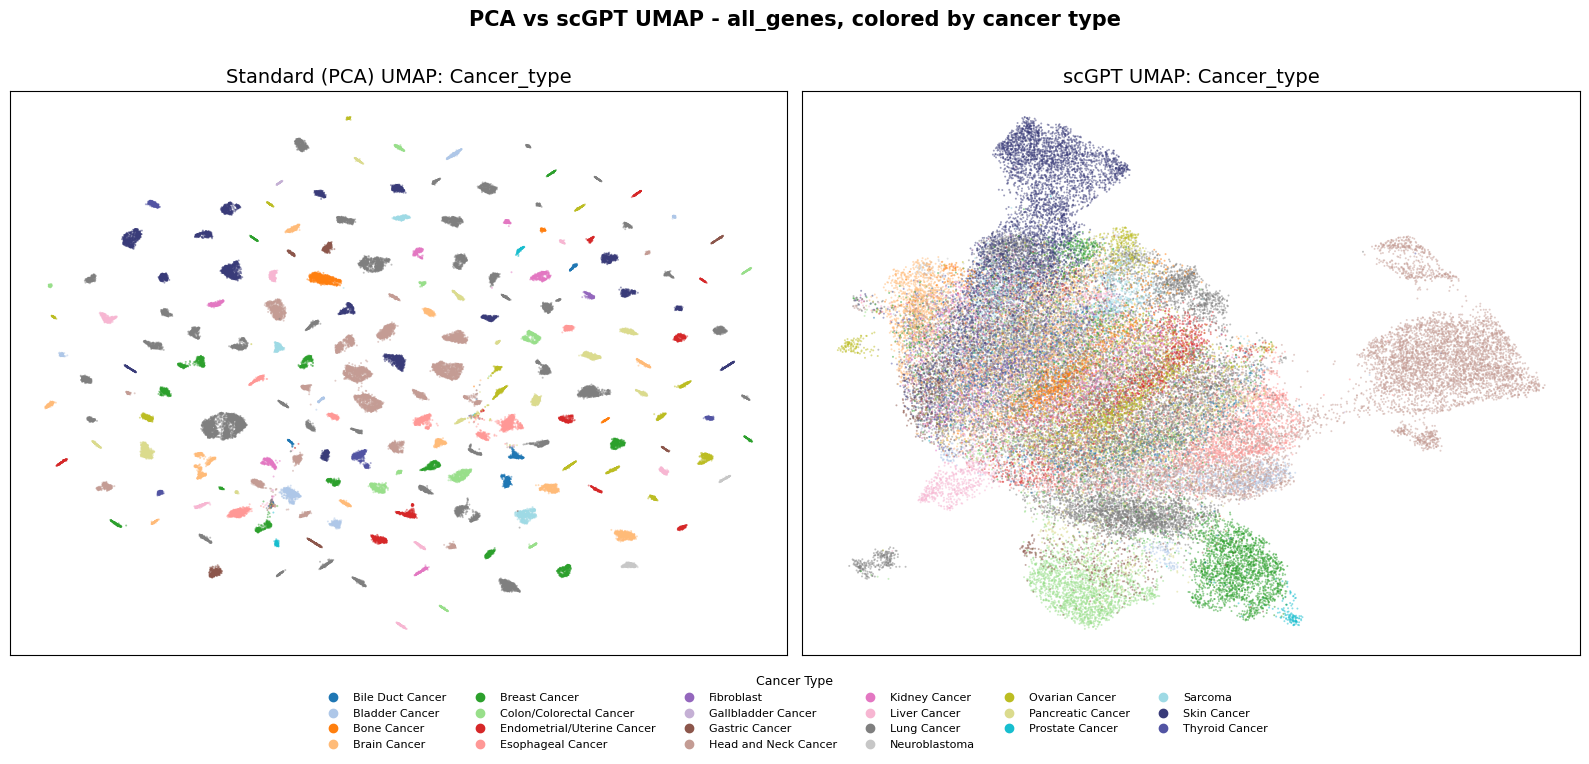

In [10]:
import sys
from pathlib import Path
import numpy as np, anndata as ad_lib, scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import PipelinePaths
# Named for the subdirectory it actually writes to. It used to be the flat outputs/ root with
# 'embeddings' re-appended at each call site, so the next write added here would have landed
# in the root (audit #24, 13.08.2026). Resolved paths are unchanged.
OUT_EMB = ROOT / 'notebooks' / 'outputs' / 'embeddings'; OUT_EMB.mkdir(parents=True, exist_ok=True)

VARIANT, SEED = 'all_genes', 42         # full transcriptome; seed 42 project-wide (was 0, which matched the original slide)
# obsm only (backed read keeps the big .X on disk)
src = sc.read_h5ad(PipelinePaths.build(None, VARIANT).targets_h5ad, backed='r')
a = ad_lib.AnnData(X=np.zeros((src.n_obs, 1), dtype='float32'), obs=src.obs.copy())
a.obsm['X_pca'] = np.asarray(src.obsm['X_pca'], dtype='float32')
a.obsm['X_scGPT'] = np.asarray(src.obsm['X_scGPT'], dtype='float32')

coords = {}
for rep in ['X_pca', 'X_scGPT']:
    nk = f'nn_{rep}'
    sc.pp.neighbors(a, use_rep=rep, n_neighbors=15, random_state=SEED, key_added=nk)
    sc.tl.umap(a, random_state=SEED, neighbors_key=nk)
    coords[rep] = a.obsm['X_umap'].copy()

cats = sorted(a.obs['Cancer_type'].astype(str).unique())
pal = plt.colormaps['tab20'].colors + plt.colormaps['tab20b'].colors
colmap = {c: pal[i % len(pal)] for i, c in enumerate(cats)}
cvec = a.obs['Cancer_type'].astype(str).map(colmap).to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(16, 7.5))
for axx, rep, t in [(ax[0], 'X_pca', 'Standard (PCA) UMAP: Cancer_type'),
                    (ax[1], 'X_scGPT', 'scGPT UMAP: Cancer_type')]:
    U = coords[rep]
    axx.scatter(U[:, 0], U[:, 1], c=cvec, s=2, alpha=0.5, linewidths=0)
    axx.set_title(t, fontsize=14); axx.set_xticks([]); axx.set_yticks([])
h = [Line2D([0], [0], marker='o', ls='', ms=6, color=colmap[c]) for c in cats]
fig.legend(h, cats, title='Cancer Type', loc='lower center', ncol=6, fontsize=8,
           title_fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'PCA vs scGPT UMAP - {VARIANT}, colored by cancer type', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0.10, 1, 0.97])
fig.savefig(OUT_EMB / 'umap_cancertype_pca_vs_scgpt.png', dpi=300, bbox_inches='tight'); plt.show()

### 8b. Full gene-set sweep grid (PCA vs scGPT × 1k/2k/3k/5k/all_genes)

/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


skip hvg2000 (missing)
skip hvg3000 (missing)


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


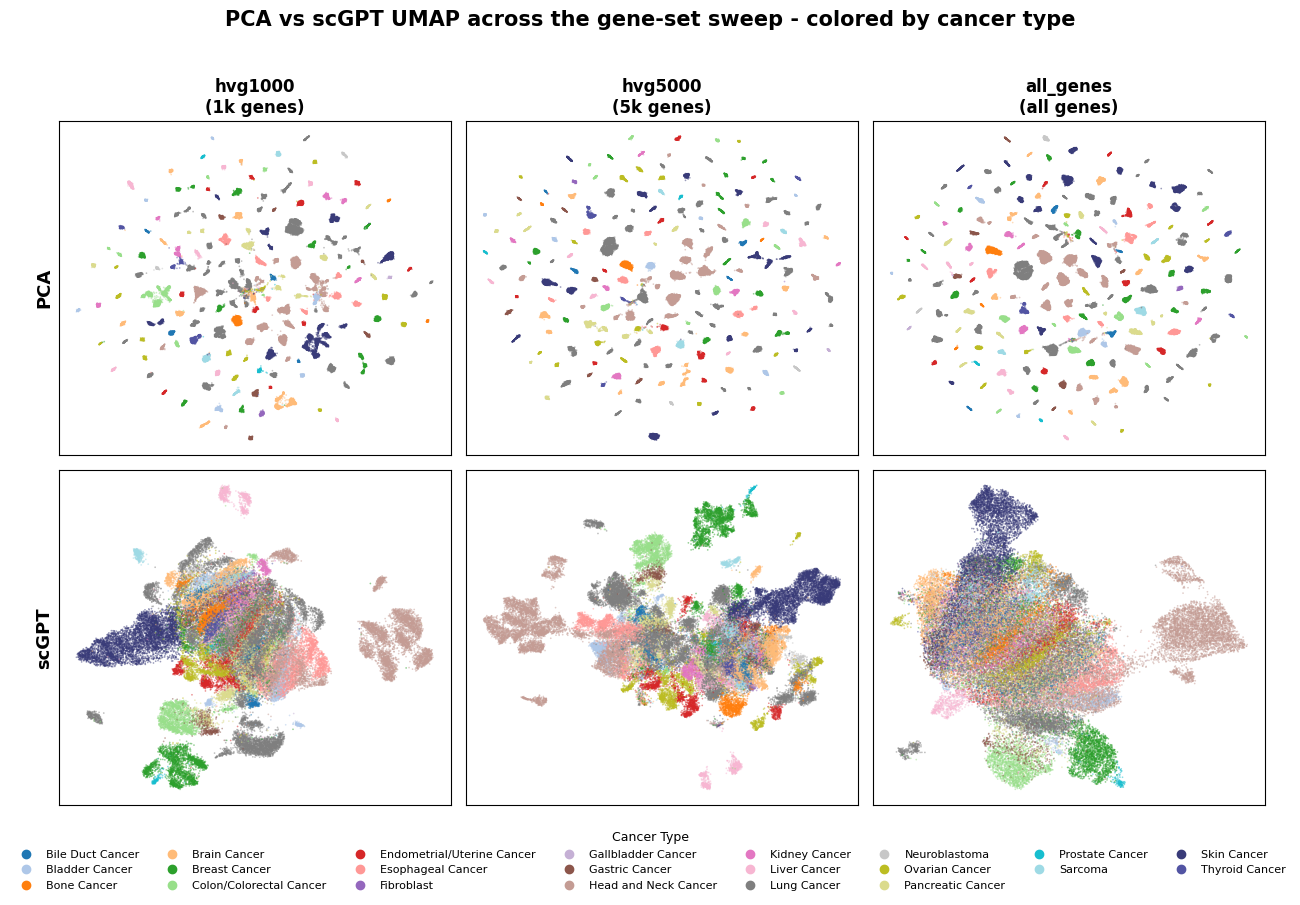

In [11]:
VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']
REPS = ['X_pca', 'X_scGPT']

coords, cancer, present = {}, None, []
for v in VARIANTS:
    p = PipelinePaths.build(None, v).targets_h5ad
    if not Path(p).exists():
        print('skip', v, '(missing)'); continue
    src = sc.read_h5ad(p, backed='r')
    a = ad_lib.AnnData(X=np.zeros((src.n_obs, 1), dtype='float32'), obs=src.obs.copy())
    for rep in REPS:
        a.obsm[rep] = np.asarray(src.obsm[rep], dtype='float32')
    if cancer is None:
        cancer = a.obs['Cancer_type'].astype(str).to_numpy()
    for rep in REPS:
        nk = f'nn_{rep}'
        sc.pp.neighbors(a, use_rep=rep, n_neighbors=15, random_state=SEED, key_added=nk)
        sc.tl.umap(a, random_state=SEED, neighbors_key=nk)
        coords[(v, rep)] = a.obsm['X_umap'].copy()
    present.append(v); del a, src

cats = sorted(np.unique(cancer))
pal = plt.colormaps['tab20'].colors + plt.colormaps['tab20b'].colors
colmap = {c: pal[i % len(pal)] for i, c in enumerate(cats)}
cvec = np.array([colmap[c] for c in cancer])
glabel = {'hvg1000': '1k', 'hvg2000': '2k', 'hvg3000': '3k', 'hvg5000': '5k', 'all_genes': 'all'}

fig, axes = plt.subplots(2, len(present), figsize=(4.2 * len(present), 9), squeeze=False)
for j, v in enumerate(present):
    for i, rep in enumerate(REPS):
        ax = axes[i][j]; U = coords[(v, rep)]
        ax.scatter(U[:, 0], U[:, 1], c=cvec, s=1.5, alpha=0.5, linewidths=0)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f'{v}\n({glabel.get(v, v)} genes)', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel({'X_pca': 'PCA', 'X_scGPT': 'scGPT'}[rep], fontsize=13, fontweight='bold')
h = [Line2D([0], [0], marker='o', ls='', ms=6, color=colmap[c]) for c in cats]
fig.legend(h, cats, title='Cancer Type', loc='lower center', ncol=8, fontsize=8,
           title_fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('PCA vs scGPT UMAP across the gene-set sweep - colored by cancer type',
             fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(OUT_EMB / 'umap_sweep_cancertype.png', dpi=200, bbox_inches='tight'); plt.show()

## 9. HVG sweet spot — heads-beating vs gene count (all drugs, under CV)

The quantitative counterpart to §8b. That grid shows *visually* that the PCA-islands / scGPT-manifold
split holds at every gene count; this section asks whether gene-set size changes **predictive**
performance. 5-fold GroupKFold heads-beating for each variant, **all 545 drugs**, both reps, test held
out — spanning **1k → 5k HVG plus `all_genes`** (plotted at its convert gene count ≈ 22.7k on a log
axis), so HVG-vs-all-genes is apples-to-apples under identical CV. Also reports Δmse per variant.
Variants without data are skipped; build them with `1_preprocessing.ipynb` §B (heavy scGPT re-embed).
About 10 trainings per available variant, so it loads a cached CSV unless `RECOMPUTE_SWEEP = True`.

> **Moved here from `2_training.ipynb` §4 on 03.08.2026** and switched from the retired `mean_pv`
> target to `auc`. The `mean_pv` numbers quoted in Step 05 came from
> `outputs/archive/training_545_mean_pv/hvg_sweep.csv`; they are **superseded** and are no longer read
> by this notebook. Nothing here is a live result until it has been re-run on `auc`.


In [12]:
# --- §9 setup: self-contained, since the cells above never import the training stack ---
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt
from scripts.layout import PipelinePaths
from scripts.training.train_multitask import cv_evaluate
from scripts.training.training_utils import TrainConfig

OUT_SWEEP = ROOT / 'notebooks' / 'outputs' / 'embeddings'
SWEEP_CSV = OUT_SWEEP / 'hvg_sweep_auc.csv'
SWEEP_PNG = OUT_SWEEP / 'hvg_sweep_auc_curve.png'

# Explicit, NOT inherited from layout.DEFAULT_CTRP_SCORE: the cache and the compute branch must
# agree on the target, or a recompute silently overwrites one target's numbers with another's.
SCORE = 'auc_cc'
SWEEP_VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']
SWEEP_REPS = ['X_pca', 'X_scGPT']
N_CV_SPLITS, EPOCHS, SWEEP_SEED = 5, 50, 42
# True since 13.08.2026 (Selin, Gate 2): R5 is a REAL regeneration, not a cache read.
# Was False, which loads outputs/embeddings/.../hvg_sweep_auc.csv when present. That cache does not
# currently exist, so this flag was already falling through to a retrain -- but it would have started
# reusing the moment one run wrote it, and the reuse prints "Loaded ... (set RECOMPUTE_SWEEP=True to
# rerun)", which reads as reassurance rather than as a warning. Cost, stated: §9 trains one model per
# variant in the sweep.
RECOMPUTE_SWEEP = True

# weight_decay=0.0 (Selin, 12.08.2026): under AdamW the old 1e-3 does nothing, so
# passing it would state a setting the optimizer ignores. See TrainConfig.
sweep_config = TrainConfig(epochs=EPOCHS, lr=1e-3, weight_decay=0.0, grad_clip=1.0,
                           scheduler_patience=3, early_stop_patience=10, log_every=10,
                           seed=SWEEP_SEED, loss='mse')
print(f'sweep target={SCORE}  cache={SWEEP_CSV.relative_to(ROOT)}  exists={SWEEP_CSV.exists()}')

sweep target=auc_cc  cache=notebooks/outputs/embeddings/hvg_sweep_auc.csv  exists=False


In [13]:
if not RECOMPUTE_SWEEP and SWEEP_CSV.exists():
    sweep_df = pd.read_csv(SWEEP_CSV)
    print(f'Loaded {SWEEP_CSV.relative_to(ROOT)} (set RECOMPUTE_SWEEP=True to rerun).')
else:
    rows = []
    for v in SWEEP_VARIANTS:
        pp = PipelinePaths.build(None, v, SCORE)
        if not Path(pp.targets_h5ad).exists():
            print(f'skip {v}: no {SCORE} targets yet (build with 1_preprocessing.ipynb §B).')
            continue
        # x-position = gene-set size: the HVG target for hvgN, the full convert count for all_genes.
        n_hvg = (sc.read_h5ad(pp.raw_h5ad, backed='r').n_vars if v == 'all_genes'
                 else int(v.replace('hvg', '')))
        adata = sc.read_h5ad(pp.targets_h5ad)
        for rep in SWEEP_REPS:
            # counts_h5ad is REQUIRED for any PCA rep and was missing here (fixed 13.08.2026,
            # Gate 5). This is the FOURTH call site of the same defect: Gate 1 found three in
            # 4a and fixed them, and this one was not enumerated. Under cross-validation the PCA is
            # refitted inside each fold on that fold's fitting cells, because a model input may not
            # depend on the held-out lines; without the counts file the only projection available is
            # the stored all-cells X_pca, which is exactly that leak -- so cv.fold_pca_projections_for
            # raises rather than falling back. Each variant passes ITS OWN counts file, since the
            # gene sets differ by construction across the sweep.
            folds = cv_evaluate(adata=adata, use_rep=rep, config=sweep_config,
                                n_splits=N_CV_SPLITS, drugs=None,
                                counts_h5ad=str(pp.raw_h5ad),
                                eligible_splits=('train', 'val'))
            hb = np.array([f['n_beats'] for f in folds], float)
            vm = np.array([f['best_val_mse'] for f in folds], float)
            dl = np.array([f['model_mean_mse'] - f['baseline_mean_mse'] for f in folds], float)
            rows.append({'variant': v, 'n_hvg': n_hvg, 'rep': rep, 'score': SCORE,
                         'heads_beat_mean': hb.mean(), 'heads_beat_std': hb.std(),
                         'delta_mean': dl.mean(), 'delta_std': dl.std(),
                         'val_mse_mean': vm.mean(), 'n_total': folds[0]['n_total']})
        del adata
    sweep_df = pd.DataFrame(rows)
    if not sweep_df.empty:
        SWEEP_CSV.parent.mkdir(parents=True, exist_ok=True)
        sweep_df.to_csv(SWEEP_CSV, index=False)
sweep_df

  fold 1: PCA fitted on 27516 cells -> (53513, 512)
  fold 2: PCA fitted on 28668 cells -> (53513, 512)


  fold 3: PCA fitted on 26111 cells -> (53513, 512)
  fold 4: PCA fitted on 27700 cells -> (53513, 512)


  fold 5: PCA fitted on 27137 cells -> (53513, 512)
Loaded 27516 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=459.6 | min drug coverage=7110 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=450.7 | min drug coverage=1041 cells | max drug coverage=5210 cells.
Loaded 8185 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=456.7 | min drug coverage=1246 cells | max drug coverage=8185 cells.
[cv1/5_X_pca] Training on device: mps
[cv1/5_X_pca] Multi-task mode detected (masked MSE).
[cv1/5_X_pca] Weight decay 0 on 107904 weight parameters; 1110 bias/norm parameters exempt.


[cv1/5_X_pca] Epoch [01/50] | Train MSE: 0.0502 | Val MSE: 0.0094 | LR: 1.0e-03  <- best
  best : bcl-lzh-4:0.001(n=2296), bms-195614:0.001(n=4872), mg-132:0.001(n=1938), ifosfamide:0.001(n=2914), brd-k09587429:0.001(n=4523)
  worst: ouabain:0.071(n=5210), rita:0.055(n=5081), gemcitabine:0.050(n=5210), docetaxel-tanespimycin (2-1 mol-mol):0.038(n=5081), clofarabine:0.037(n=4881)


[cv1/5_X_pca] Epoch [02/50] | Train MSE: 0.0108 | Val MSE: 0.0091 | LR: 1.0e-03  <- best
  best : brd-k09587429:0.001(n=4523), brd-k16147474:0.001(n=4523), bcl-lzh-4:0.001(n=2296), brd-k49290616:0.001(n=1634), bms-195614:0.001(n=4872)
  worst: ouabain:0.070(n=5210), rita:0.054(n=5081), gemcitabine:0.048(n=5210), neopeltolide:0.037(n=1963), docetaxel-tanespimycin (2-1 mol-mol):0.036(n=5081)


...

[cv5/5_X_scGPT] Epoch [11/50] | Train MSE: 0.0079 | Val MSE: 0.0125 | LR: 1.0e-03  <- best
  best : mg-132:0.001(n=3095), brd-k49290616:0.001(n=1264), brd-k51831558:0.001(n=3630), a-804598:0.001(n=4335), cil41:0.001(n=1547)
  worst: navitoclax-birinapant (1-1 mol-mol):0.146(n=5599), birinapant:0.112(n=5599), gemcitabine:0.110(n=5302), docetaxel:0.101(n=3755), vincristine:0.092(n=5599)


[cv5/5_X_scGPT] Epoch [15/50] | Train MSE: 0.0074 | Val MSE: 0.0124 | LR: 1.0e-03  <- best
  best : brd-k51831558:0.001(n=3630), mg-132:0.001(n=3095), brd-k49290616:0.001(n=1264), a-804598:0.001(n=4335), ml029:0.001(n=5599)
  worst: navitoclax-birinapant (1-1 mol-mol):0.141(n=5599), birinapant:0.108(n=5599), gemcitabine:0.106(n=5302), docetaxel:0.101(n=3755), vincristine:0.090(n=5599)


[cv5/5_X_scGPT] Epoch [20/50] | Train MSE: 0.0071 | Val MSE: 0.0126 | LR: 5.0e-04
  best : mg-132:0.001(n=3095), brd-k51831558:0.001(n=3630), brd-k49290616:0.001(n=1264), ifosfamide:0.001(n=1844), brd-4770:0.001(n=1264)
  worst: navitoclax-birinapant (1-1 mol-mol):0.138(n=5599), docetaxel:0.115(n=3755), gemcitabine:0.109(n=5302), birinapant:0.108(n=5599), vincristine:0.099(n=5599)


[cv5/5_X_scGPT] Early stopping at epoch 25 (no val improvement for 10 epochs).
[cv5/5_X_scGPT] Training complete. Best Val MSE: 0.0124 at epoch 15.


,variant,n_hvg,rep,score,heads_beat_mean,heads_beat_std,delta_mean,delta_std,val_mse_mean,n_total
0,hvg1000,1000,X_pca,auc_cc,275.0,26.675832,-0.000318,0.000160,0.010288,534
1,hvg1000,1000,X_scGPT,auc_cc,288.0,27.298352,-0.000426,0.000158,0.010098,534
2,hvg5000,5000,X_pca,auc_cc,284.0,28.474550,-0.000379,0.000134,0.010335,534
3,hvg5000,5000,X_scGPT,auc_cc,293.6,25.842600,-0.000456,0.000246,0.010235,534
4,all_genes,22722,X_pca,auc_cc,278.4,33.850258,-0.000334,0.000137,0.010409,534
5,all_genes,22722,X_scGPT,auc_cc,303.8,34.631777,-0.000416,0.000233,0.010201,534


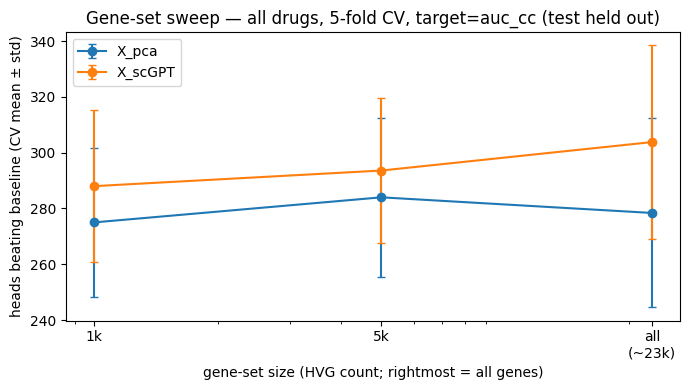

In [14]:
if sweep_df.empty or sweep_df['variant'].nunique() < 2:
    print('Need >=2 variants for the sweet-spot curve. Build them in 1_preprocessing.ipynb §B, then re-run.')
else:
    ticks = sorted(sweep_df['n_hvg'].unique())
    labels = [f'{t//1000}k' if t < 20000 else f'all\n(~{t/1000:.0f}k)' for t in ticks]
    fig, ax = plt.subplots(figsize=(7, 4))
    for rep in SWEEP_REPS:
        d = sweep_df[sweep_df.rep == rep].sort_values('n_hvg')
        ax.errorbar(d['n_hvg'], d['heads_beat_mean'], yerr=d['heads_beat_std'],
                    marker='o', capsize=3, label=rep)
    ax.set_xscale('log'); ax.set_xticks(ticks); ax.set_xticklabels(labels)
    ax.set_xlabel('gene-set size (HVG count; rightmost = all genes)')
    ax.set_ylabel('heads beating baseline (CV mean ± std)')
    ax.set_title(f'Gene-set sweep — all drugs, 5-fold CV, target={SCORE} (test held out)')
    ax.legend()
    SWEEP_PNG.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(); fig.savefig(SWEEP_PNG, dpi=150); plt.show()


## 10. Does scGPT see the gene set it was given? — `max_length` truncation

`gen_embeds.py` embeds with `max_length=1200`. Inside scGPT only a cell's **non-zero** genes become
tokens (`scgpt/tasks/cell_emb.py:75`), preceded by a `<cls>` token, and a cell whose sequence exceeds
the cap has its genes **randomly subsampled** rather than truncated in order
(`scgpt/data_collator.py:145`, `torch.randperm`). Because `keep_first_n_tokens=1` protects `<cls>`, the
effective gene budget is **1,199**, and subsampling fires at **1,200 or more** non-zero genes.

1,200 is not an arbitrary default: `scGPT_human/args.json` records `"max_seq_len": 1200` and
`"trunc_by_sample": true`, so it is the pretraining sequence length and the subsample is the operation
used during pretraining (Cui *et al.*, *Nature Methods* **21**, 1470–1480, 2024, Methods).

This governs how the gene-set axis of §8b/§9 reads. Wherever the cap binds, enlarging the gene set does
**not** hand scGPT more genes — it only changes the pool the 1,199 are drawn from. PCA reads every gene
it is given at every variant, so the two representations stop being comparable on that axis exactly
where the cap starts to bite. This section measures where.

**Counts are taken on the `embeddings` file**, which `embed_data` has already subset to scGPT's
vocabulary (`cell_emb.py:220`) — that is the matrix actually tokenized. Counting on `convert` would
credit scGPT with the out-of-vocabulary genes it never received.

The numbers in
[Step 02](../../../docs/steps/02-preprocessing-and-embeddings.md#why-hvg-5000-is-the-default-03082026)
came from an ad-hoc `h5py` pass on 03.08.2026; this section is their re-runnable replacement and
extends them from two variants to all five.

### 10a. Are the HVG variants nested?

§8b and §9 treat gene-set size as one ordered axis. That reading holds only if the smaller HVG sets are
subsets of the larger ones — scanpy's `n_top_genes` takes the top *N* of a single dispersion ranking, so
they should be, but "should be" is not a check. It also decides whether `hvg5000`'s per-cell counts
below bound the smaller variants' without measuring them separately.

In [15]:
# Gene sets come from `convert` (post-HVG, pre-OOV): nesting is a property of the HVG filter,
# not of scGPT's vocabulary.
SWEEP_VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']

gene_sets = {v: set(load(v, 'convert').var_names) for v in SWEEP_VARIANTS}

rows = []
for smaller, larger in zip(SWEEP_VARIANTS, SWEEP_VARIANTS[1:]):
    outside = gene_sets[smaller] - gene_sets[larger]
    rows.append({'smaller': smaller, 'genes': len(gene_sets[smaller]), 'larger': larger,
                 'not contained in larger': len(outside), 'nested': not outside})
pd.DataFrame(rows)

,smaller,genes,larger,not contained in larger,nested
0,hvg1000,1000,hvg2000,0,True
1,hvg2000,2000,hvg3000,0,True
2,hvg3000,3000,hvg5000,2,False
3,hvg5000,5000,all_genes,0,True


### 10b. Non-zero genes per cell, and where the cap binds

One chunked pass over each `embeddings` file's `.X`. All five are stored **dense** `float64`, so there is
no sparse index to read off and the non-zeros have to be counted; `all_genes` is an ~8.8 GB
decompression. Per-cell counts are cached to `outputs/embeddings/scgpt_nonzero_per_cell.npz` (~1 MB) so
the pass is paid once — set `RECOMPUTE_COUNTS = True` to redo it. Caching the per-cell vector rather than
the summary means any later question about the distribution does not require the pass again.

In [16]:
import h5py

CAP = 1200                 # scGPT max_length (gen_embeds.py); == scGPT_human/args.json "max_seq_len"
GENE_BUDGET = CAP - 1      # <cls> takes one slot and keep_first_n_tokens=1 protects it -> 1,199 genes
CHUNK = 2048               # 2,048 x 20,570 x 8 B ~ 340 MB per block for all_genes
# True since 13.08.2026 (Selin, Gate 2), and this one was actively biting. The cache
# outputs/embeddings/scgpt_nonzero_per_cell.npz IS committed and present, so with False this cell
# loaded per-cell non-zero counts computed from embeddings that PREDATE the gene-symbol repair
# (4,576 -> 4,704 in-vocabulary genes for hvg5000) and printed "Loaded ... (set RECOMPUTE_COUNTS=True
# to rerun)". After R2 those numbers describe a gene set the pipeline no longer uses, and nothing in
# the output would have said so -- notebooks/outputs/README.md meanwhile promised this directory is
# "regenerated by verify_variants at R5", which under the old default it was not.
RECOMPUTE_COUNTS = True

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
COUNTS_NPZ = ROOT / 'notebooks' / 'outputs' / 'embeddings' / 'scgpt_nonzero_per_cell.npz'

if not RECOMPUTE_COUNTS and COUNTS_NPZ.exists():
    counts = {v: a for v, a in np.load(COUNTS_NPZ).items()}
    print(f'Loaded {COUNTS_NPZ.relative_to(ROOT)} (set RECOMPUTE_COUNTS=True to rerun).')
else:
    counts = {}
    for v in SWEEP_VARIANTS:
        with h5py.File(DATA_ROOT / v / FILES['embeddings'], 'r') as f:
            X = f['X']                       # dense (n_cells, n_invocab_genes), verified for all five
            n_cells, n_genes = X.shape
            c = np.empty(n_cells, dtype=np.int32)
            for i in range(0, n_cells, CHUNK):
                c[i:i + CHUNK] = np.count_nonzero(X[i:i + CHUNK], axis=1)
        counts[v] = c
        print(f'{v:>10}: {n_genes:>6,} in-vocab genes | mean {c.mean():>6.0f} expressed/cell '
              f'| {(c >= CAP).sum():>6,} cells at or above the cap')
    COUNTS_NPZ.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(COUNTS_NPZ, **counts)
    print(f'Cached to {COUNTS_NPZ.relative_to(ROOT)}')

   hvg1000:    939 in-vocab genes | mean    122 expressed/cell |      0 cells at or above the cap
   hvg2000:  1,846 in-vocab genes | mean    257 expressed/cell |      0 cells at or above the cap


   hvg3000:  2,771 in-vocab genes | mean    373 expressed/cell |      0 cells at or above the cap


   hvg5000:  4,765 in-vocab genes | mean    673 expressed/cell |    174 cells at or above the cap


 all_genes: 21,332 in-vocab genes | mean   3723 expressed/cell | 53,513 cells at or above the cap
Cached to notebooks/outputs/embeddings/scgpt_nonzero_per_cell.npz


### 10c. Summary — what scGPT actually received per variant

`genes actually seen` is the number that governs how §8b/§9 read: it is `min(expressed, 1199)` averaged
over cells, i.e. the input the model really got, as opposed to the gene-set size the variant is named
after. Where it falls below the mean expressed count, the variant's label overstates what scGPT saw.

In [17]:
# n_vars per variant: shape only, no data read.
n_invocab = {}
for v in SWEEP_VARIANTS:
    with h5py.File(DATA_ROOT / v / FILES['embeddings'], 'r') as f:
        n_invocab[v] = f['X'].shape[1]

rows = []
for v in SWEEP_VARIANTS:
    c = counts[v]
    capped = c >= CAP
    rows.append({
        'variant': v,
        'genes after HVG': len(gene_sets[v]),
        'in scGPT vocab': n_invocab[v],
        'expressed/cell: min': int(c.min()),
        'median': int(np.median(c)),
        'mean': round(float(c.mean())),
        'max': int(c.max()),
        'cells >= cap': int(capped.sum()),
        '% cells capped': round(100 * float(capped.mean()), 3),
        'genes actually seen (mean)': round(float(np.minimum(c, GENE_BUDGET).mean())),
        '% kept, capped cells': (round(100 * float(np.median(GENE_BUDGET / c[capped])), 1)
                                 if capped.any() else None),
    })
pd.DataFrame(rows).set_index('variant')

,genes after HVG,in scGPT vocab,expressed/cell: min,median,mean,max,cells >= cap,% cells capped,genes actually seen (mean),"% kept, capped cells"
variant,,,,,,,,,,
hvg1000,1000,939,36,119,122,277,0,0.000,122,NaN
hvg2000,2000,1846,91,253,257,555,0,0.000,257,NaN
hvg3000,3000,2771,150,367,373,790,0,0.000,373,NaN
hvg5000,5000,4765,302,662,673,1407,174,0.325,672,96.9
all_genes,22722,21332,1937,3629,3723,8159,53513,100.000,1199,33.0
